In [1]:
from trim.model import *
from trim.computation import *
from trim.entresults import *
import trim.infocore as ifc
from trim.analysis import visualisation_conditioned,decision_tree
import matplotlib.pyplot as plt
from sklearn import metrics
import pandas as pd
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import os

In [2]:
data_dir = os.path.join('..', 'data')

# Figure 3

In [3]:
#Initialising the network
n_nodes = 10
edge_list = [[1,2],[1, 4],[1,6],[3,6],[3,8],[3,10],[4,9],[5,7],[5,8],[6,7],[8,9],[9,10]]
n_edges = len(edge_list)
B = create_node_edge_incidence_matrix(edge_list)
K = np.array([
    [0, 0, 0, 0, 0,0,0,0,0,0], [0,0,-1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,1,0,0], 
    [0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0],[0,0,0,-1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,1,0,0]
])

#Initialising and running the model
model = NDwTIs(
    B=B, K=K, w_pos=8, w_neg=0.5,
    threshold=1e-3, alpha=0.05, noise_std=1*(1e-2),
    x_init=np.zeros(n_nodes), dt=1e-2, t_max=4000.)
timeseries = model.run()
timeseries = np.array(timeseries)
timeseries = timeseries[:,-200000::5]

Sigma, T, Tn 0.3337280875182716 1.284192264908007 0.5421237789267415
Sigma_mean_null 0.11459414386135154
T_mean_null 0.6803215432738592
Tn_mean_null 0.540288022234237
P 0.5 P_T 0.5 P_Tn 0.5
Theta 138.64123510999818 Theta_T 15.87616732942046 Theta_Tn 0.3751404616111748


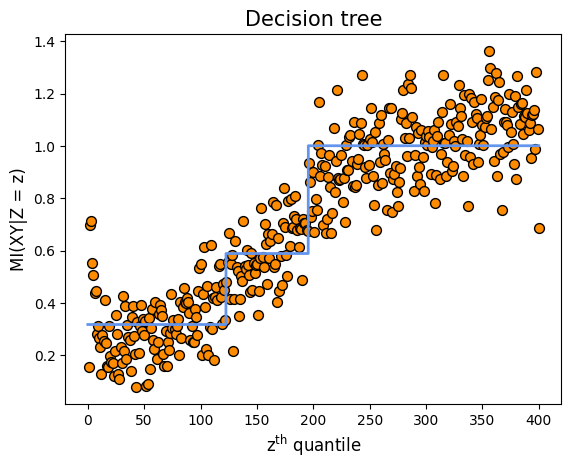

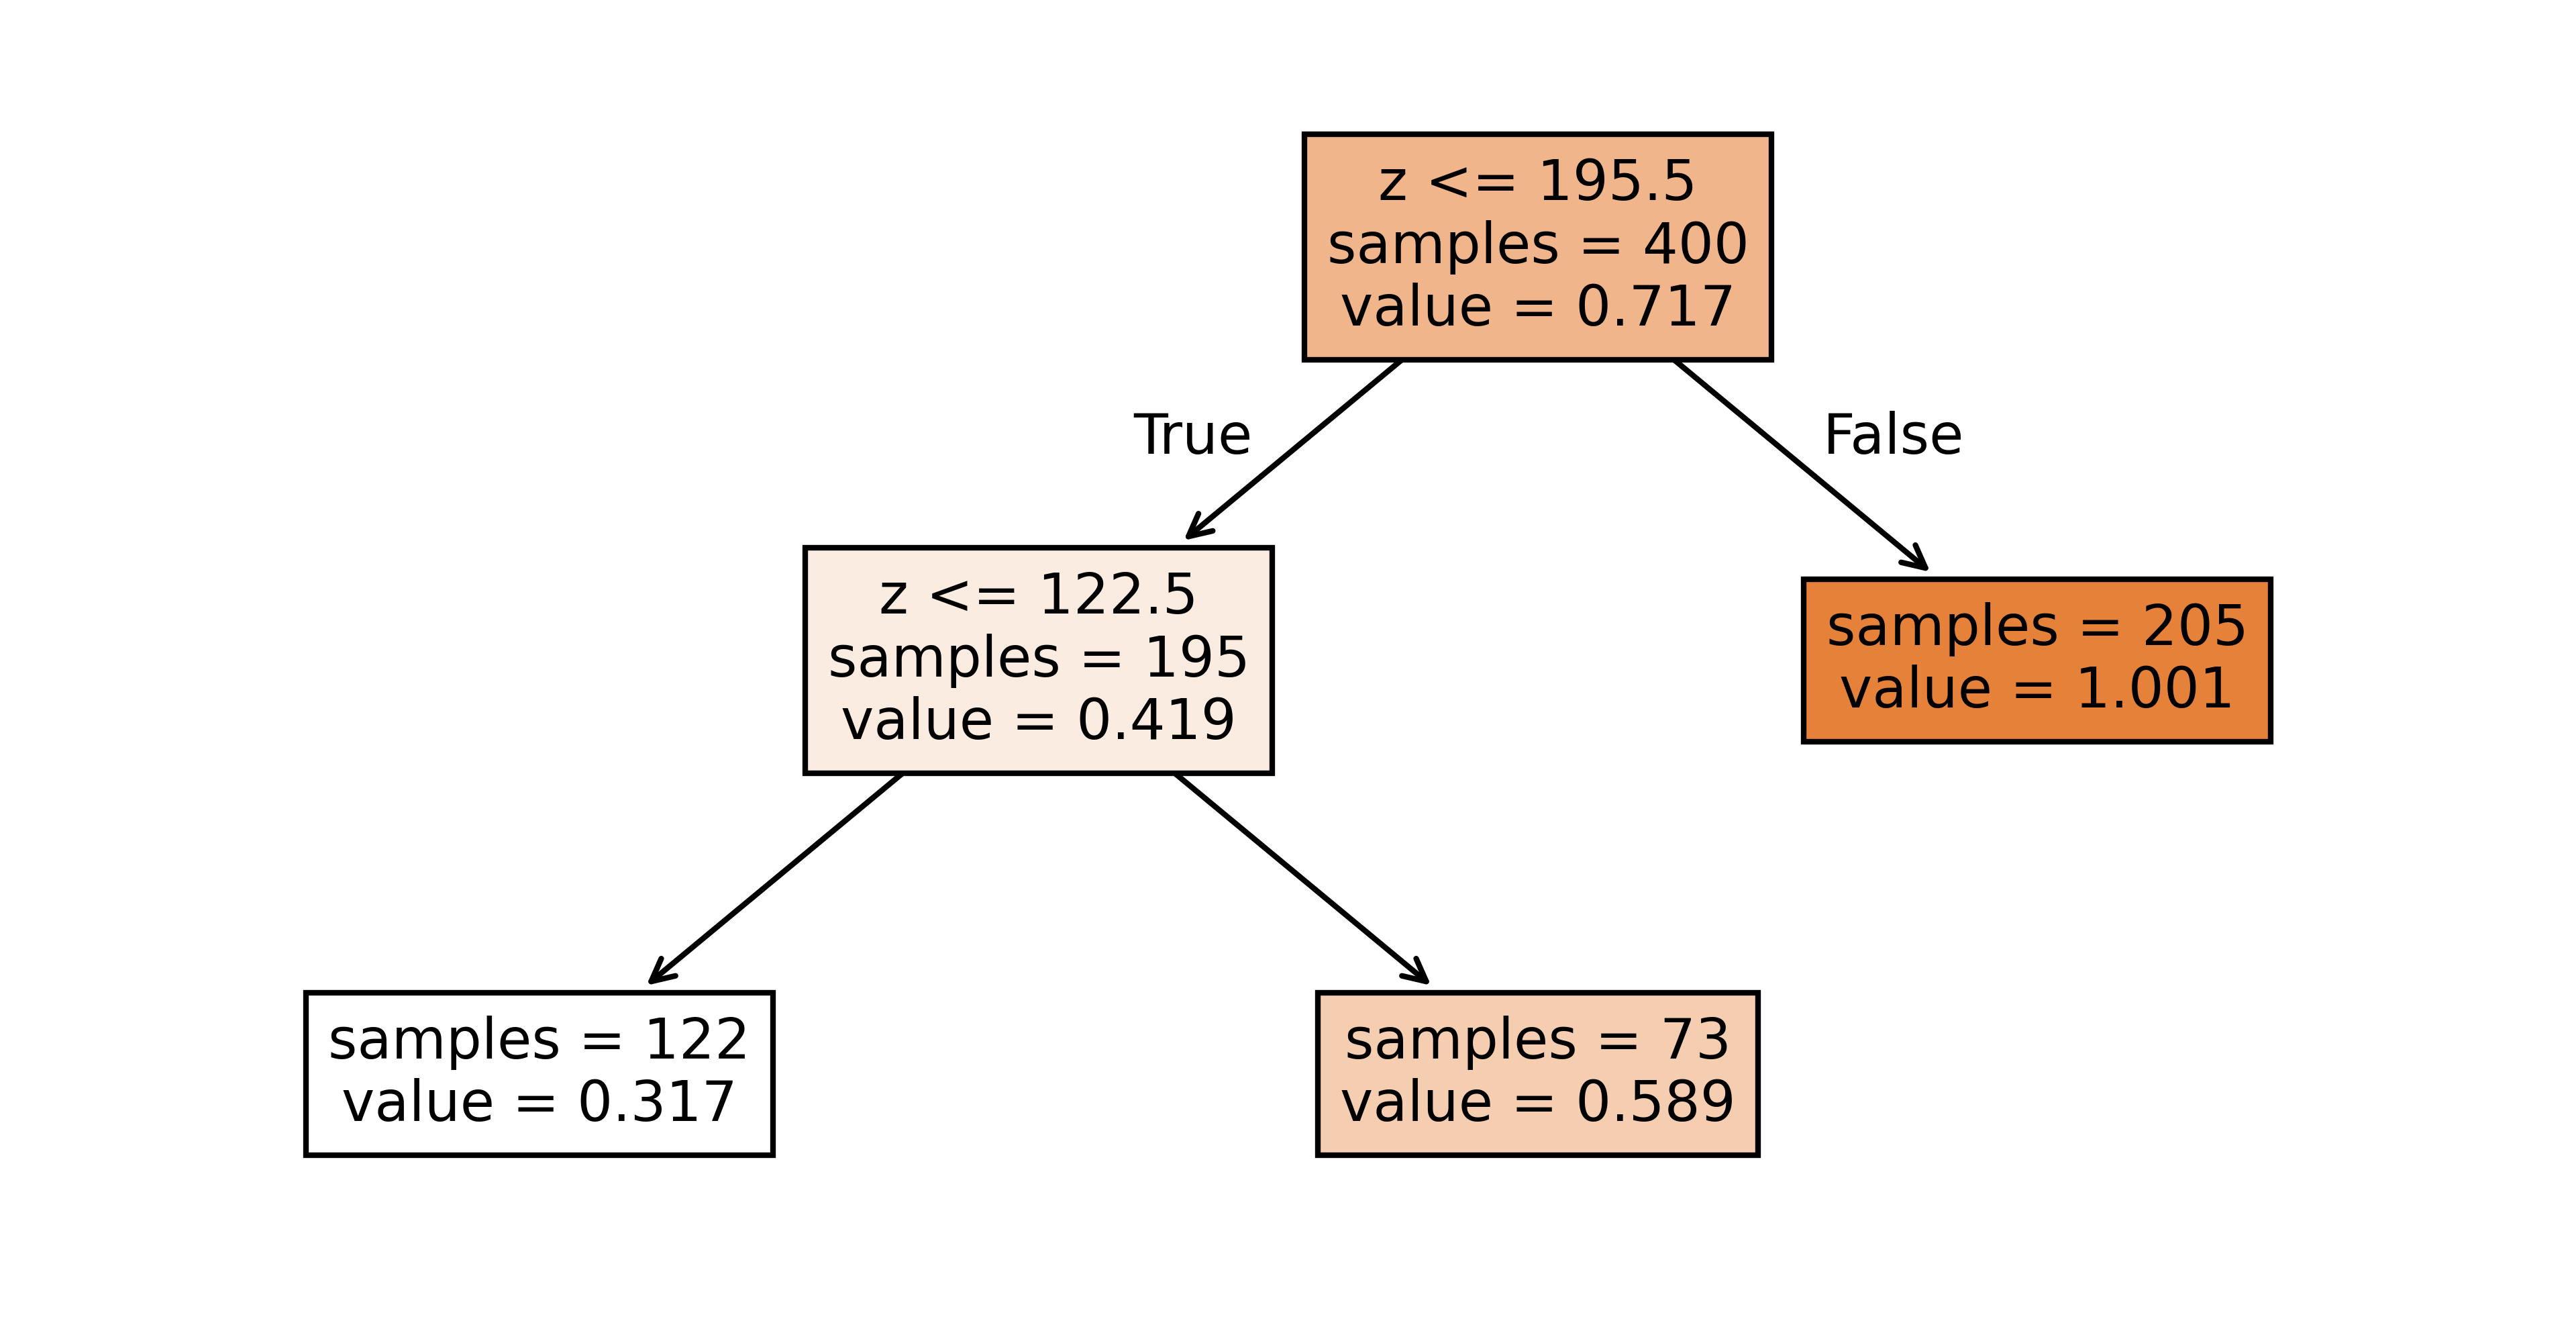

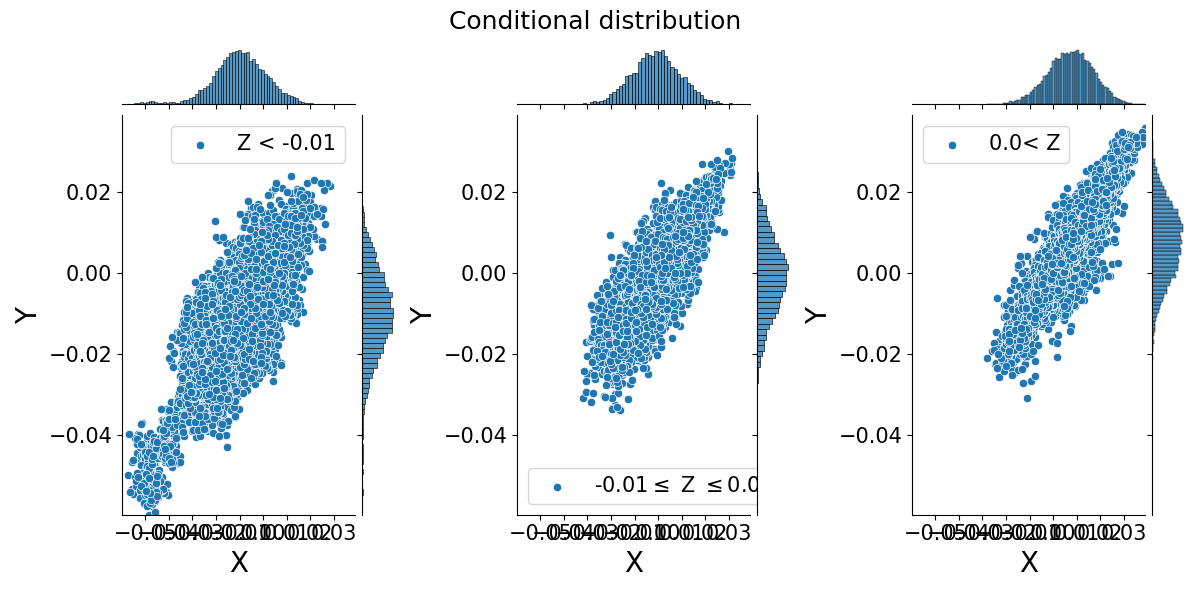

In [4]:
#TRIM algorithm for triple 4,9,5
tlen = 40000
num = round(tlen/100)
nrunmax = 2
I=[4,9,5]
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, False, True)
x = np.arange(1, num+1)
#Producing the figures
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,disp_tree=True)
I = np.array(I)-1
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])

# Figure 4

Sigma, T, Tn 0.1009625085691091 0.8162292801719251 0.41831278964905794
Sigma_mean_null 0.10090589791839305
T_mean_null 0.6034562385198066
Tn_mean_null 0.5545681210966342
P 0.5 P_T 0.5 P_Tn 1.0
Theta 0.019624699973945087 Theta_T 38.392316838501316 Theta_Tn 2.5033043085694735


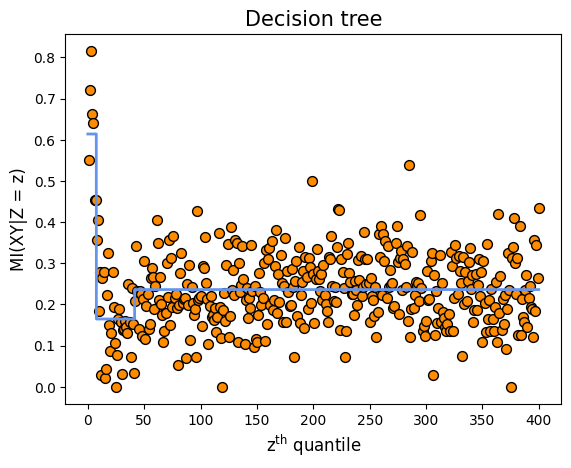

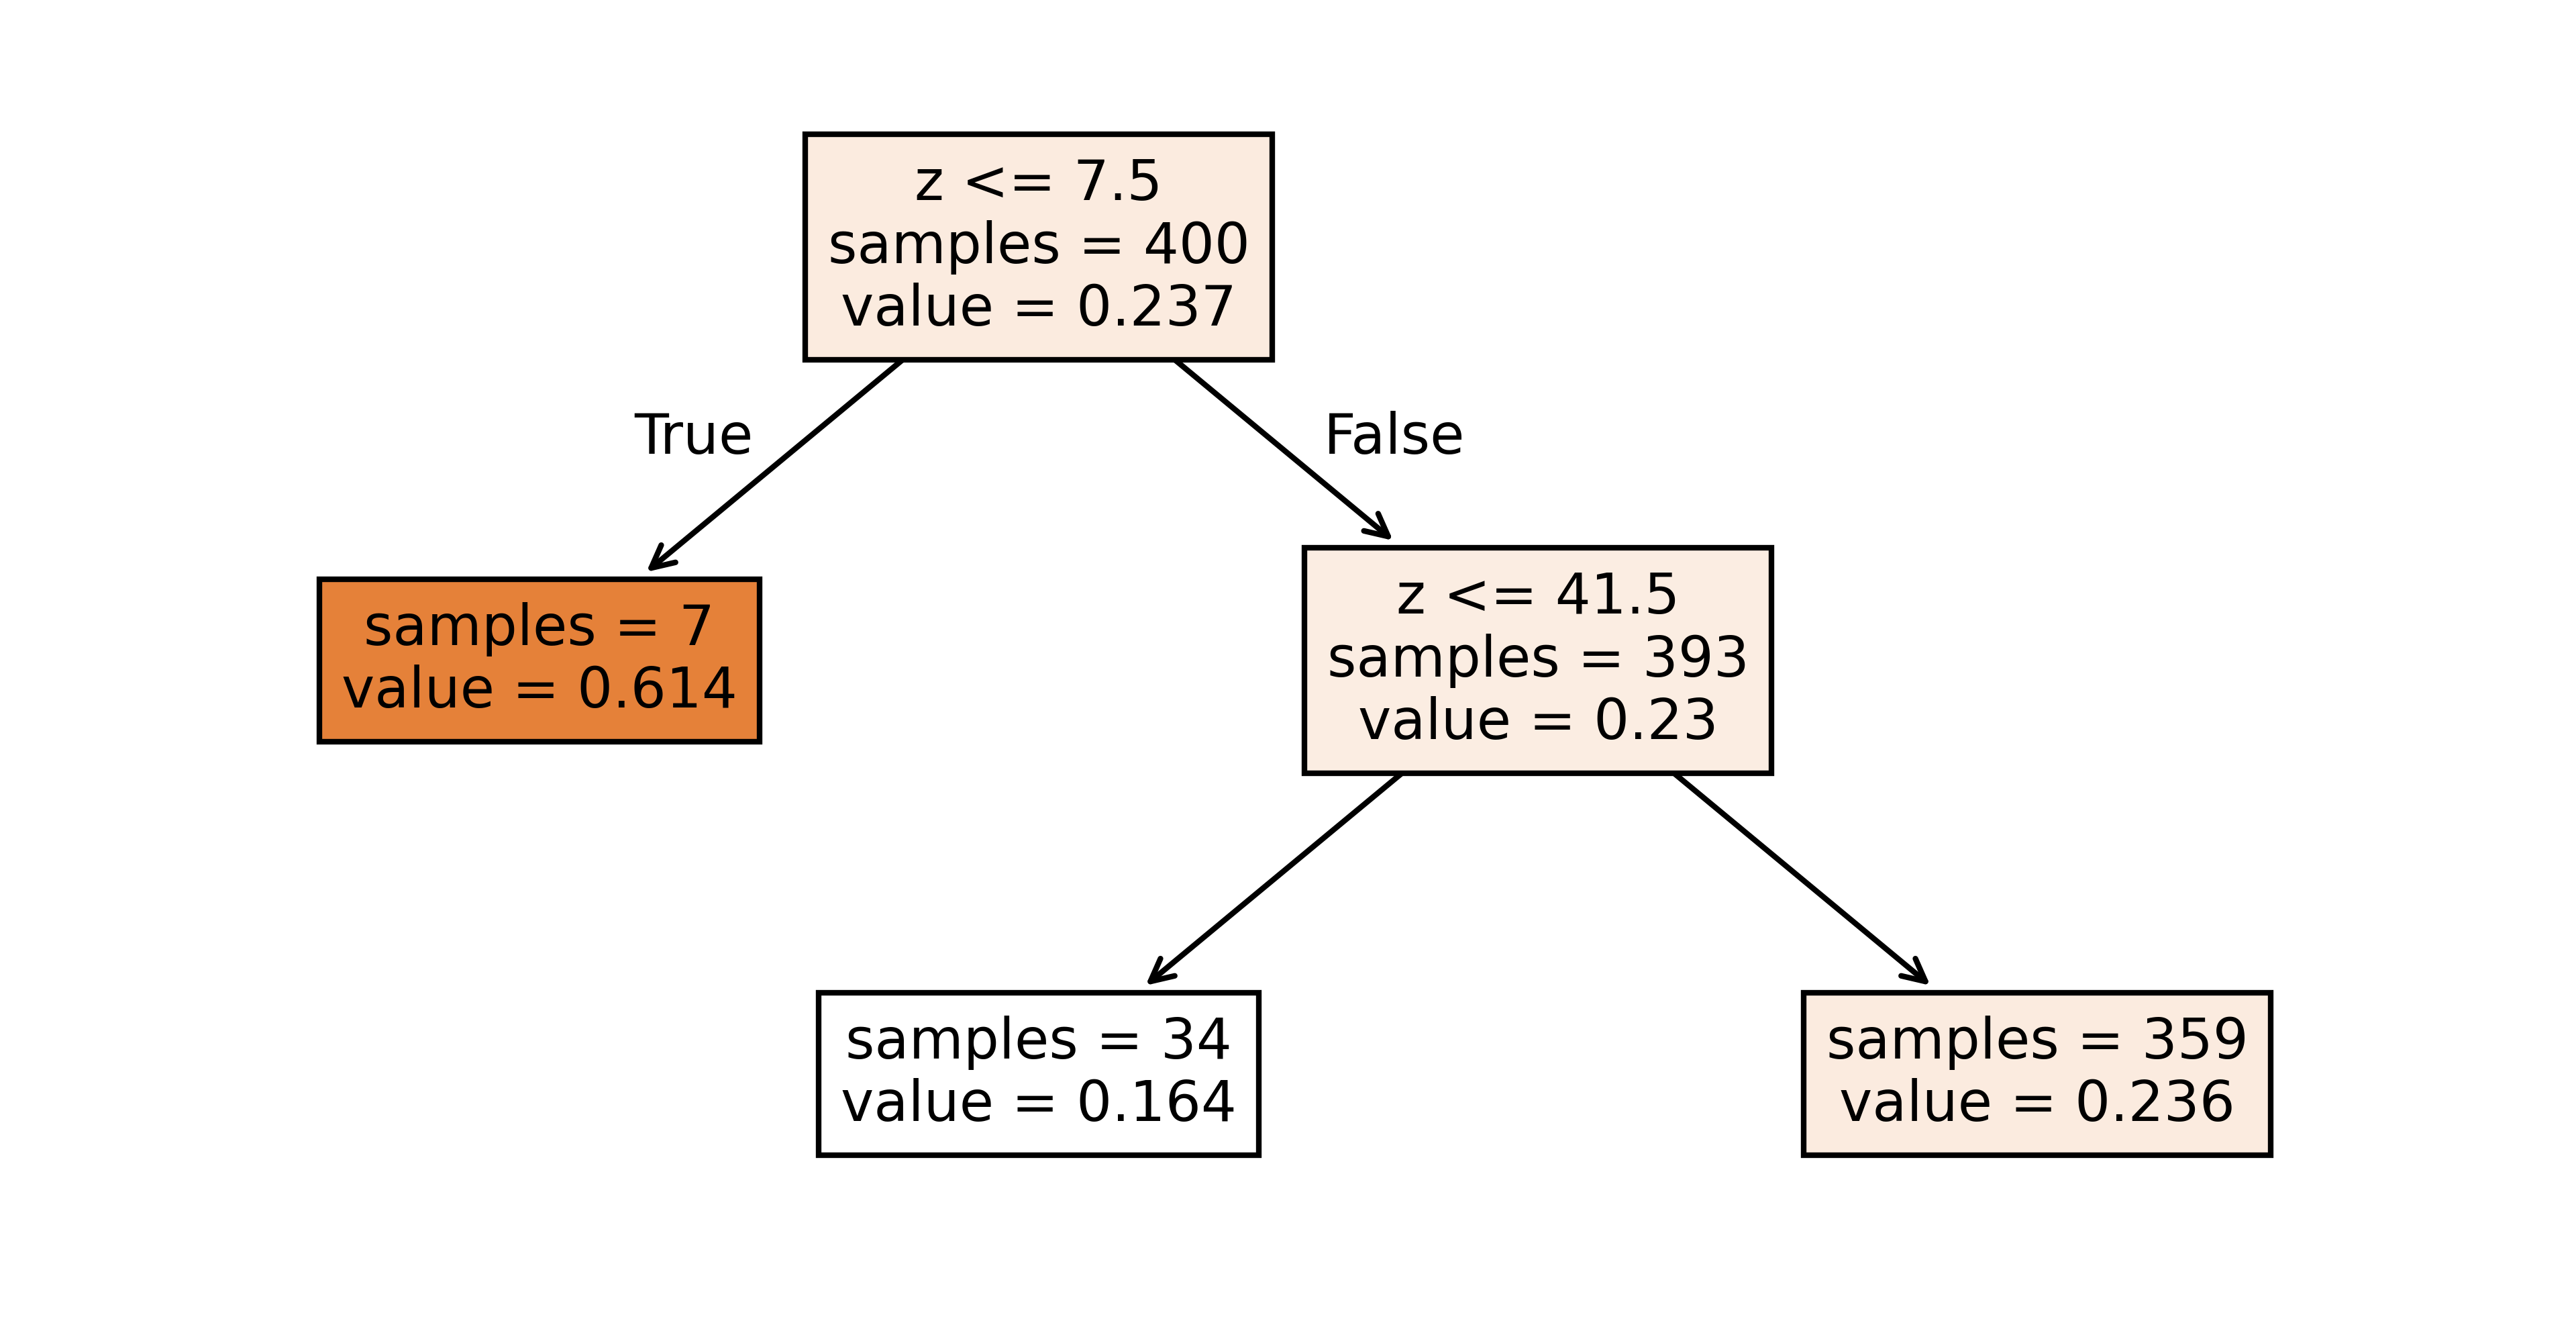

In [5]:
#TRIM algorithm for triple 1,2,6
tlen = 40000
num = round(tlen/100)
nrunmax = 2
I=[1,2,6]
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, False, True)
x = np.arange(1, num+1)
#Producing the figures
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True, disp_tree=True)

# Figure 5 

In [6]:
#Processing and formatting the results of the analysis of the small (N=10) network
edges2 = edge_processing([
    os.path.join(data_dir, 'EdgeT', 'edgeT12.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT14.txt'),
    os.path.join(data_dir, 'EdgeT', 'edgeT16.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT36.txt'),
    os.path.join(data_dir, 'EdgeT', 'edgeT38.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT310.txt'),
    os.path.join(data_dir, 'EdgeT', 'edgeT49.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT57.txt'),
    os.path.join(data_dir, 'EdgeT', 'edgeT58.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT67.txt'),
    os.path.join(data_dir, 'EdgeT', 'edgeT89.txt'),os.path.join(data_dir, 'EdgeT', 'edgeT910.txt')
])
edge_ROC = pd.read_csv(os.path.join(data_dir, 'ROC005-5.csv'))
edge_ROC_2 = pd.read_csv(os.path.join(data_dir, 'ROC005-1.csv'))

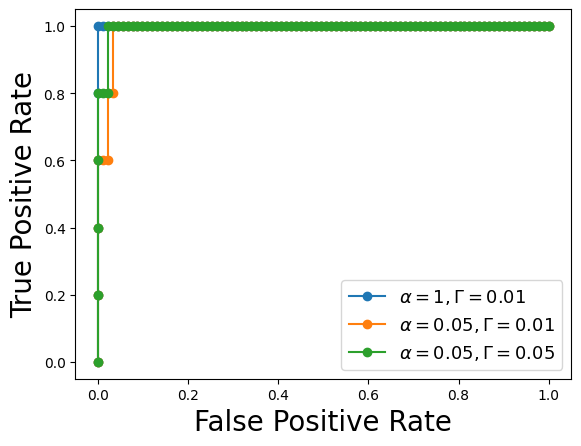

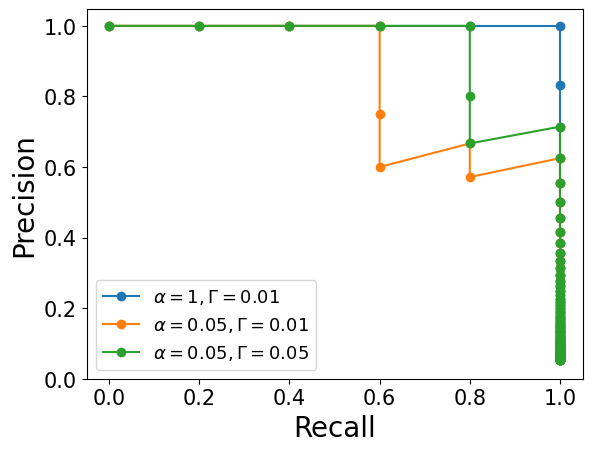

In [7]:
#Plotting the ROC curve
y = np.array([0,0,0,0,0,0,0,0,
              0,0,1,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,1,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,1,0,
              0,0,0,0,1,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,1])
scores2 = np.ndarray.flatten(edges2[:,:,1])
scores_ROC = edge_ROC['Theta_Sigma'].tolist()
scores_ROC_2 = edge_ROC_2['Theta_Sigma'].tolist()
fpr2, tpr2, thresholds = metrics.roc_curve(y, scores2,drop_intermediate=False)
fpr_roc,tpr_roc, thresholds = metrics.roc_curve(y,scores_ROC,drop_intermediate=False)
fpr_roc2,tpr_roc2, thresholds = metrics.roc_curve(y,scores_ROC_2,drop_intermediate=False)
plt.figure()
plt.plot(fpr2,tpr2,'o-',label=r'$\alpha = 1, \Gamma = 0.01$')
plt.plot(fpr_roc2,tpr_roc2,'o-',label=r'$\alpha = 0.05, \Gamma = 0.01$')
plt.plot(fpr_roc,tpr_roc,'o-',label=r'$\alpha = 0.05, \Gamma = 0.05$')
plt.legend(fontsize=13)
plt.ylabel('True Positive Rate',fontsize=20)
plt.xlabel('False Positive Rate',fontsize=20)
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
#plt.savefig('ROC-curve.png',dpi=600,bbox_inches="tight")

f1, t1, thresholds = metrics.precision_recall_curve(y, scores2)
froc, troc, thresholds = metrics.precision_recall_curve(y,scores_ROC)
froc2,troc2, thresholds = metrics.precision_recall_curve(y,scores_ROC_2)
plt.figure()
plt.plot(t1,f1,'o-',label=r'$\alpha = 1, \Gamma = 0.01$')
plt.plot(troc2,froc2,'o-',label=r'$\alpha = 0.05, \Gamma = 0.01$')
plt.plot(troc,froc,'o-',label=r'$\alpha = 0.05, \Gamma = 0.05$')
plt.legend(fontsize=13)
plt.yticks(np.arange(0, 1.2, step=0.2))
plt.ylabel('Precision',fontsize=20)
plt.xlabel('Recall',fontsize=20)
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
#plt.savefig('PR-curve.png',dpi=600,bbox_inches="tight")

# Figure 6

<Figure size 640x480 with 0 Axes>

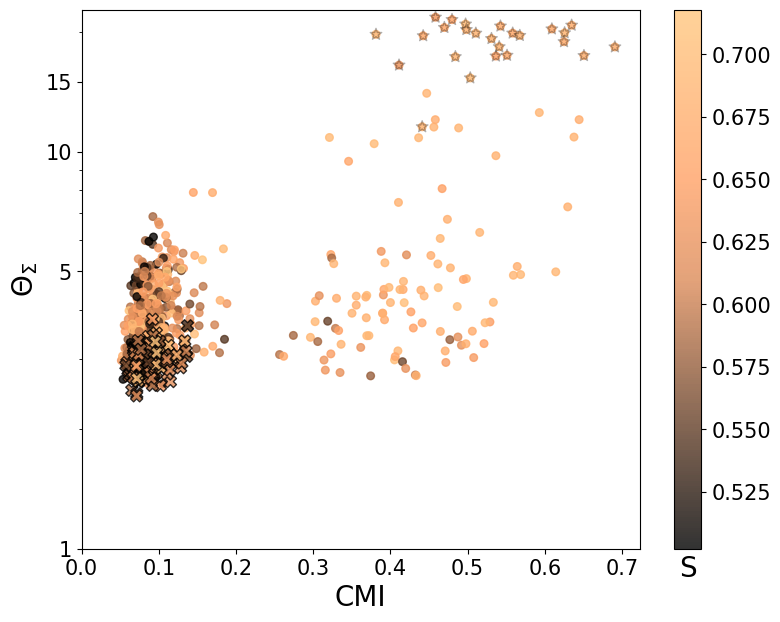

In [8]:
synth_trip_S = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'ran_t_S_norm.csv'))
synth_trip_S = synth_trip_S.dropna()
synth_cr_S = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'ran_cr_S_norm.csv'))
G = nx.read_gml(os.path.join(data_dir, 'ran_100_t_matrices', 'network_100_t'), destringizer=int)
K = np.load(os.path.join(data_dir, 'ran_100_t_matrices', 'Kmat_100_t.npy'))
Elist=nx.edges(G)
Elist=np.array(Elist)
Elist = Elist + 1
Elist = Elist.tolist()
x1 = np.where(K==-1)
x2 = np.where(K==1)
y1 = [[float(Elist[x1[0][i]][0]),float(Elist[x1[0][i]][1]),float(x1[1][i]+1)] for i in range(len(x1[0]))]
y2 = [[float(Elist[x2[0][i]][0]),float(Elist[x2[0][i]][1]),float(x2[1][i]+1)] for i in range(len(x2[0]))]
ran_true = pd.DataFrame()
for i in y1+y2:
    test = synth_trip_S[synth_trip_S['node1'] == i[0]]
    test = test[test['node2']==i[1]]
    test = test[test['reg']==i[2]]
    ran_true = pd.concat([ran_true, test])

plt.figure()
MI_MIC_merge(synth_trip_S,ran_true,synth_cr_S, key = 'S', display = 2.5, label = None) 

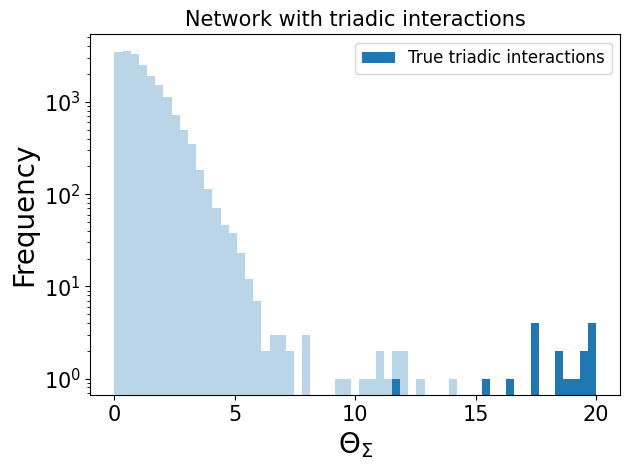

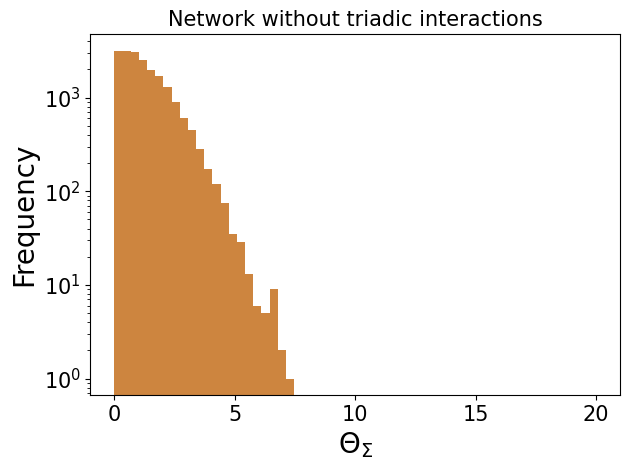

In [9]:
ran_t_0_alt = pd.read_csv(os.path.join(data_dir, 'ran_100_t_P100_0.csv'))
ran_t = pd.read_csv(os.path.join(data_dir, 'ran_100_t_P100.csv'))
plt.figure()
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
plt.hist(ran_t['Theta_Sigma'],bins=np.linspace(0,20,60),alpha=0.3,facecolor='tab:blue')
plt.hist(ran_true['Theta_Sigma'],bins=np.linspace(0,20,60),
         label='True triadic interactions',alpha=1,color='tab:blue')
plt.yscale('log')
plt.xlabel(r'$\Theta_\Sigma$', fontsize=20, color='black')
plt.ylabel('Frequency', fontsize=20, color='black')
plt.legend(fontsize=12)
plt.title('Network with triadic interactions',fontsize=15)
plt.tight_layout()

plt.figure()
plt.hist(ran_t_0_alt['Theta_Sigma'],bins=np.linspace(0,20,60),
         label='Network excluding triadic interactions',alpha=1,color='peru')
plt.yscale('log')
plt.xlabel(r'$\Theta_\Sigma$', fontsize=20, color='black')
plt.ylabel('Frequency', fontsize=20, color='black')
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
plt.title('Network without triadic interactions',fontsize=15)
plt.tight_layout()

# Figure 7

Graph:


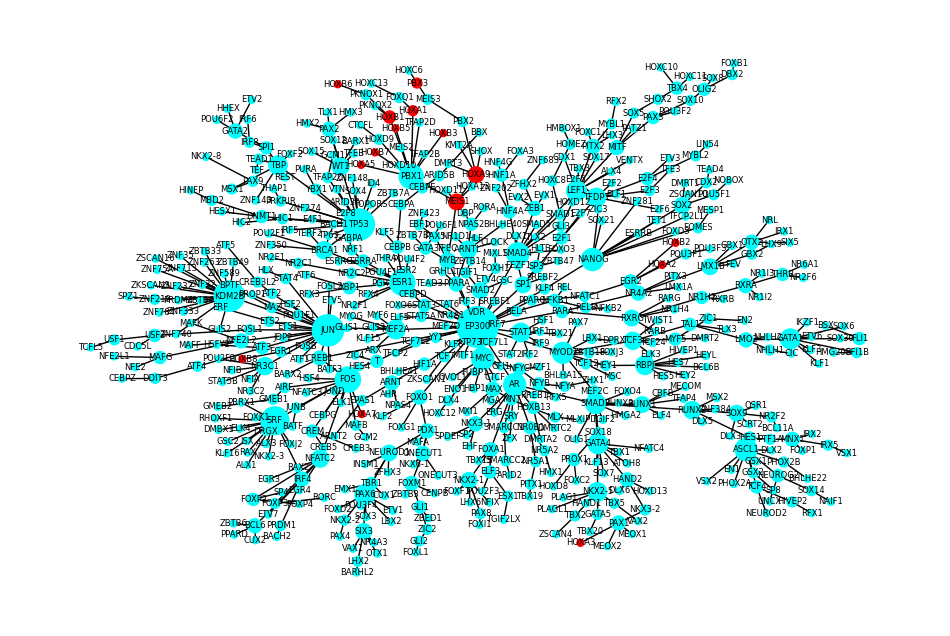

In [10]:
#Constructing the Maximal Spanning Tree from the PPI Edge Data
ppi = pd.read_csv(os.path.join(data_dir, 'reduce_ppi.tsv'), sep = '\t')
graph_ppi = nx.from_pandas_edgelist(ppi, source = '0', target = '1',edge_attr='2')
T = nx.maximum_spanning_tree(graph_ppi,weight = '2')
L = ['HOXA1','HOXA2','HOXA3','HOXA4','HOXA5','HOXA6','HOXA7','HOXA8','HOXA9','HOXB1','HOXB2','HOXB3','HOXB4','HOXB5','HOXB6','HOXB7','HOXB8','HOXB9','PBX3','MEIS1']
fig = plt.figure(figsize=(12,8))
Gcc = sorted(nx.connected_components(T), key=len, reverse=True)
G0 = T.subgraph(Gcc[0])
f = nx.Graph()
fedges = filter(lambda x: G0.degree()[x[0]] > 0 and G0.degree()[x[1]] > 0, G0.edges())
f.add_edges_from(fedges)
color_map=[]
NodeSize = []
for n in f.nodes:
    NodeSize.append(G0.degree(n)*25)
    if n in L:
        color_map.append('red')
    else:
        color_map.append('cyan')
pos = graphviz_layout(T, prog="fdp")
nx.draw(f,node_size=NodeSize,pos=pos,ax=fig.add_subplot(),node_color=color_map)
nx.draw_networkx_labels(f,pos=pos,font_size=6)
print('Graph:')

# Figure 8

0.2399152595790664


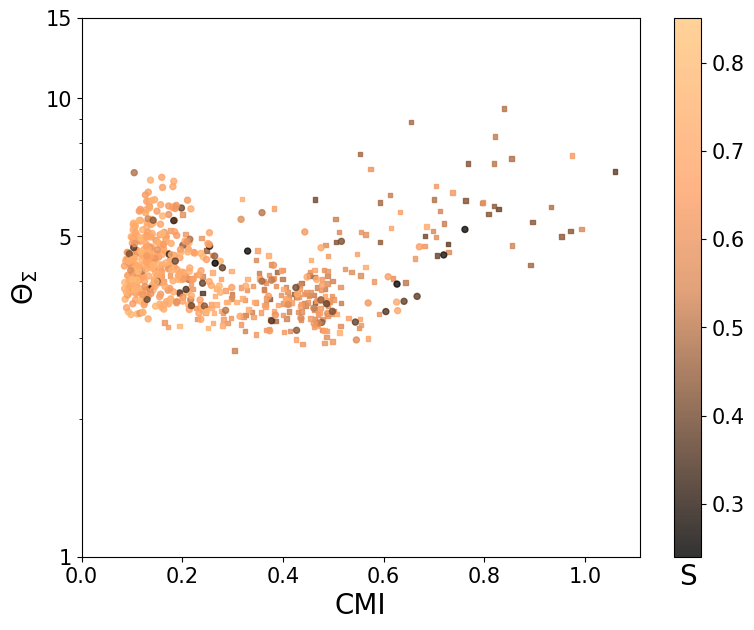

In [11]:
gene_alg = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'ran_tri_5_norm.csv'))
CR = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'cr_tri_5_norm.csv'))
bio_cr = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'cr_bio_5_norm_2.csv'))
CR = pd.concat([CR,bio_cr])
gene_alg = gene_alg.dropna()
CR = CR.dropna()
Bio_out_S = pd.read_csv(os.path.join(data_dir, 'Merge_data', 'ran_bio_5_norm_2.csv'))
empty = CR[CR['reg']=='???']
MI_MIC_merge(Bio_out_S, gene_alg, empty, key = 'S', display = 4, label = None)

In [12]:
gene_expression = pd.read_csv(os.path.join(data_dir, 'reduce_gene_expression.tsv'), sep = '\t', index_col=0)

Sigma, T, Tn 0.3846935279042448 0.9251806630931907 0.6393281170241394
Sigma_mean_null 0.13401236554862017
T_mean_null 0.3681324633038192
Tn_mean_null 0.3197630335691514
P 0.01 P_T 0.01 P_Tn 0.01
Theta 5.547818129533536 Theta_T 4.411307729217432 Theta_Tn 2.624193411411069


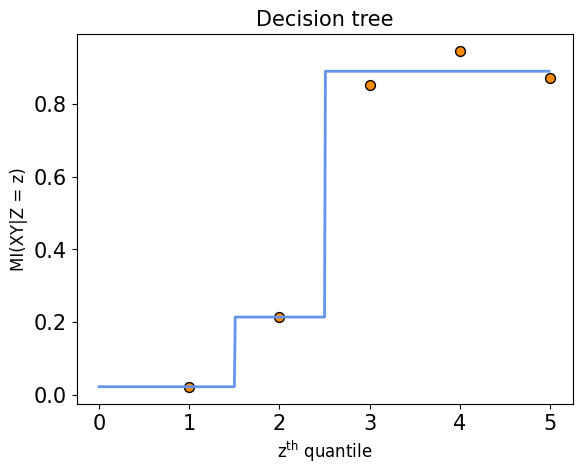

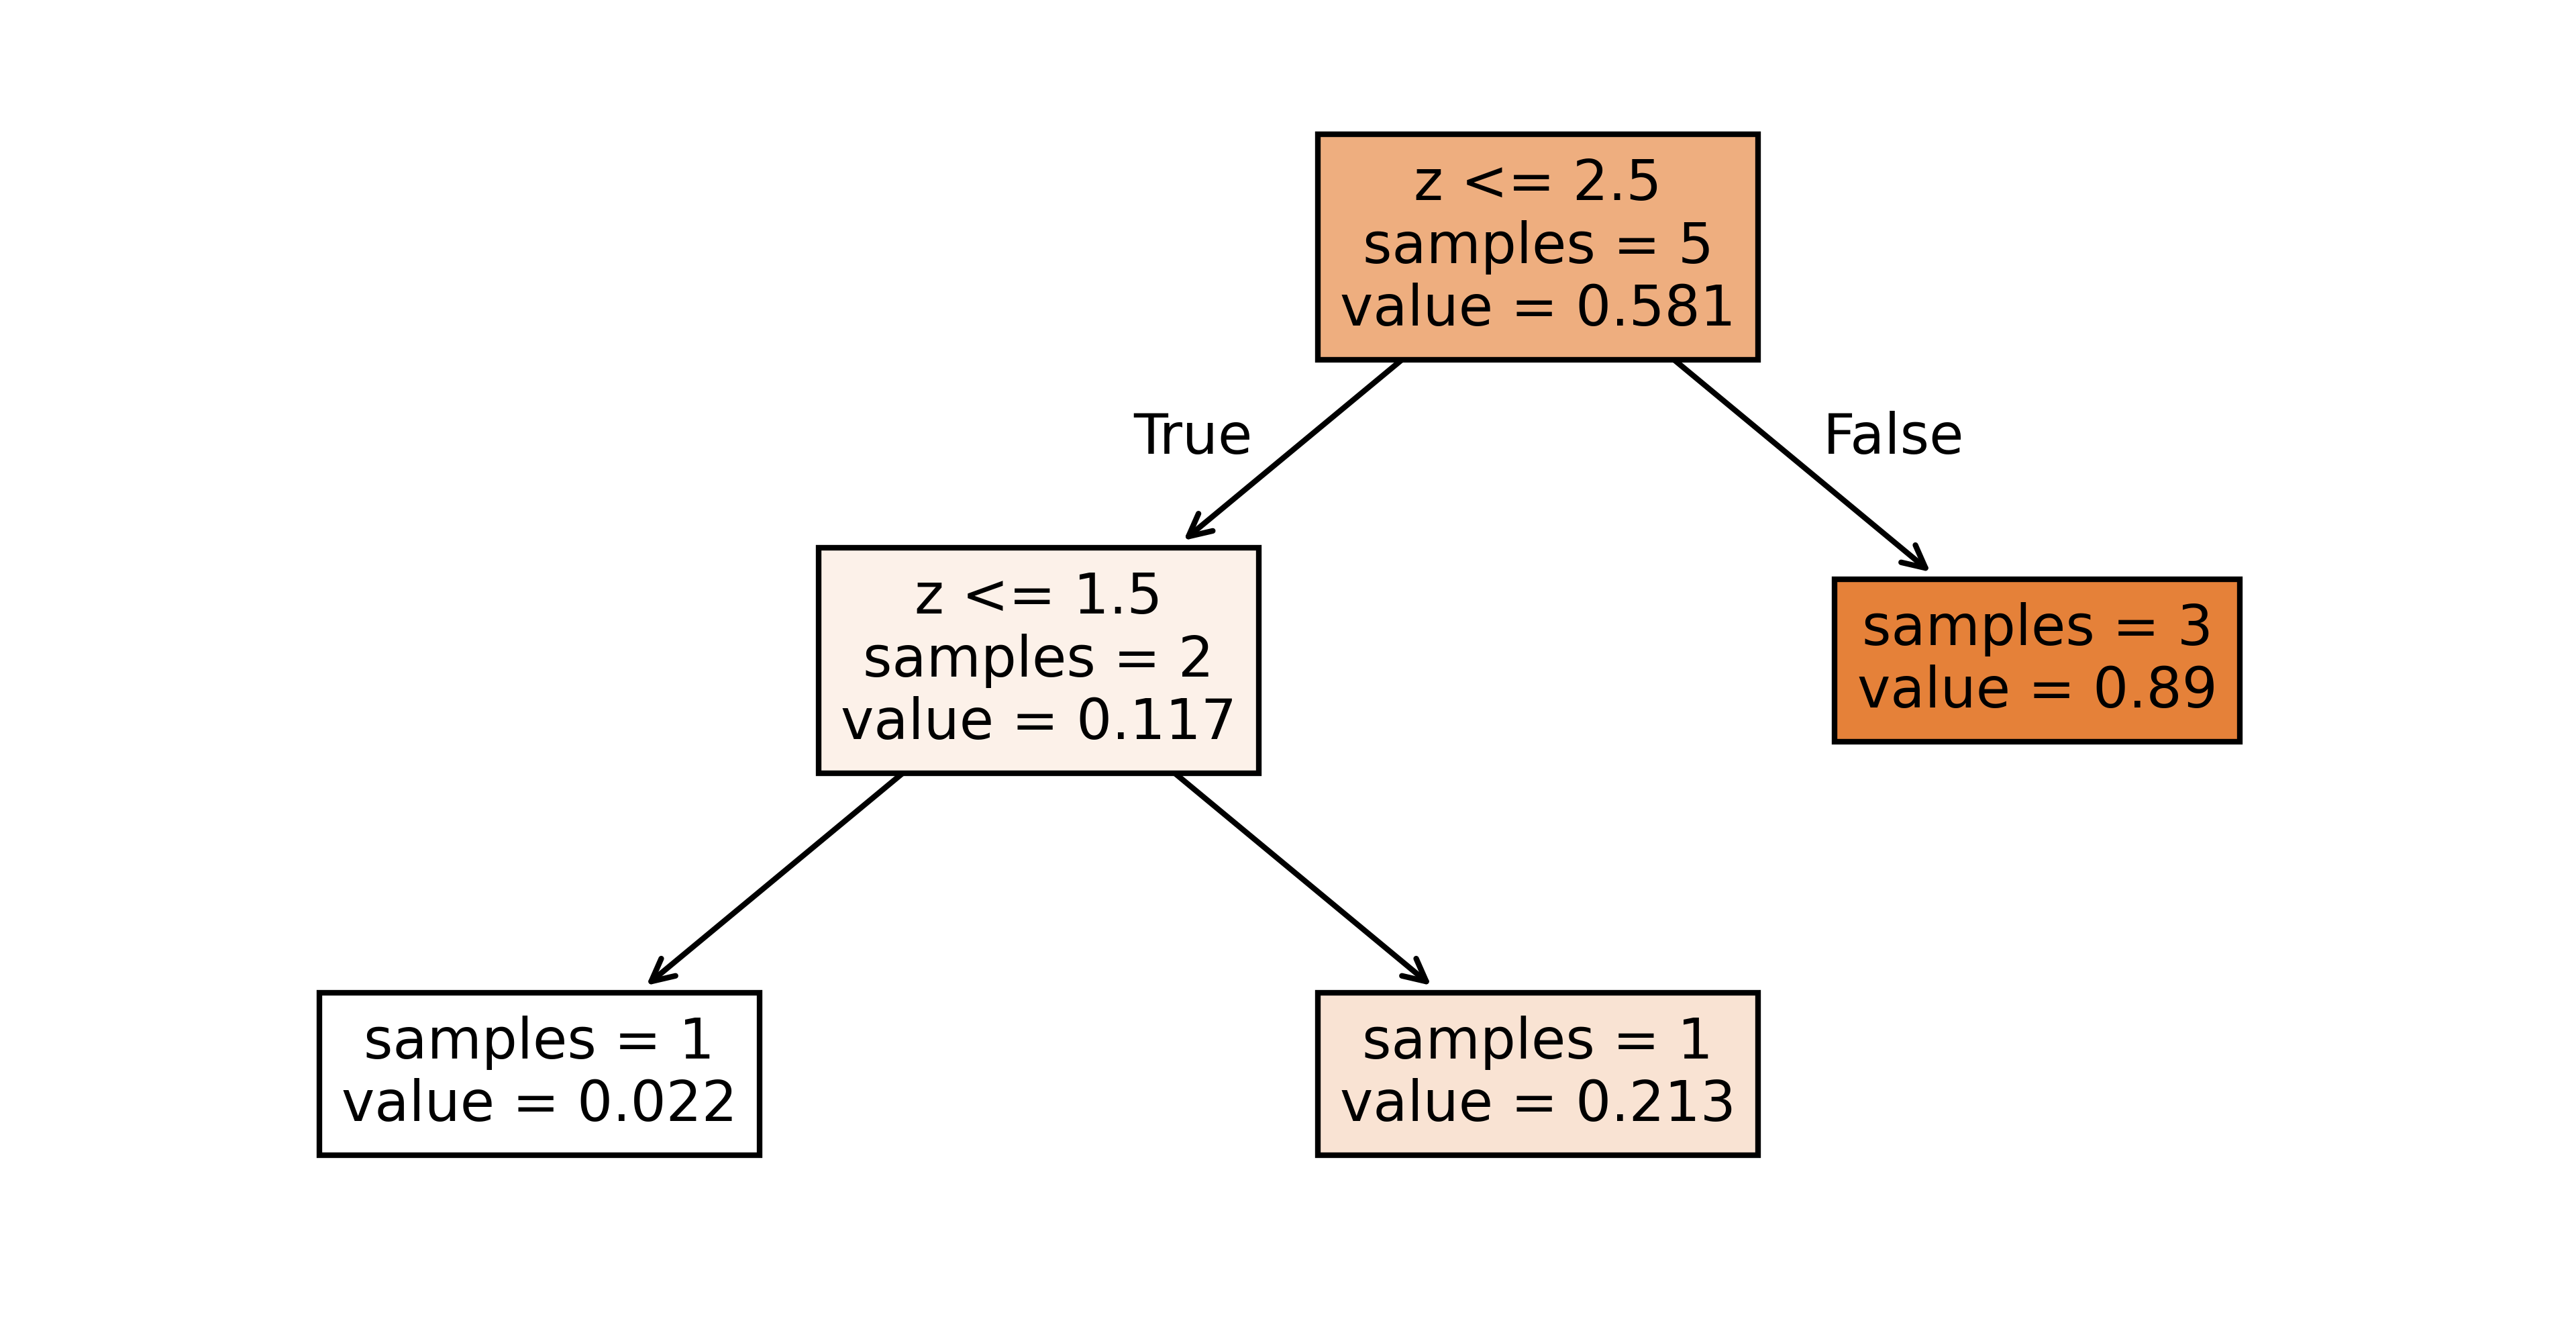

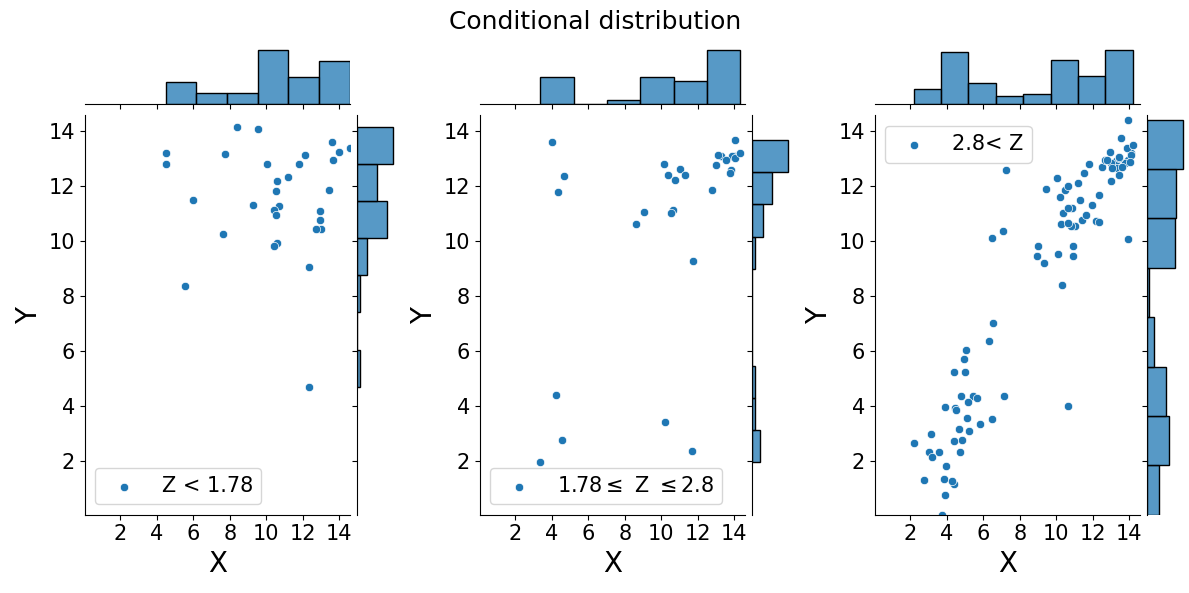

In [13]:
#getting Timeseries data for genes
name_X = 'HOXB3'
name_Y = 'MEIS1'
name_Z = 'GLIS3'

X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 100
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1, th2, c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True, name=None)
I = [0,1,2]
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])

Sigma, T, Tn 0.4407285194367151 1.0260321296350707 0.9351831637861043
Sigma_mean_null 0.13946286407136976
T_mean_null 0.3853399062023098
Tn_mean_null 0.3286115309867398
P 0.0001 P_T 0.0001 P_Tn 0.0001
Theta 6.034700692265014 Theta_T 4.532815477724908 Theta_Tn 4.456860255690802


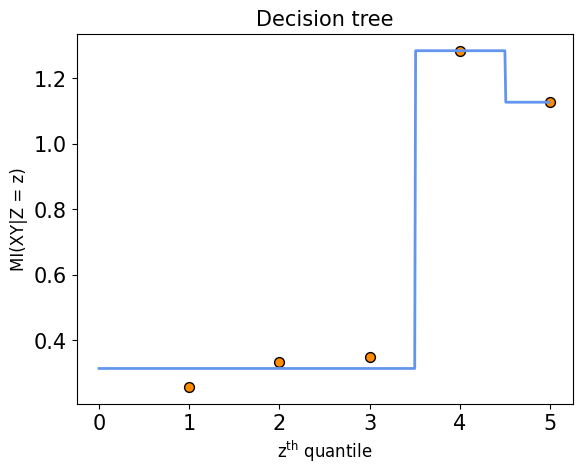

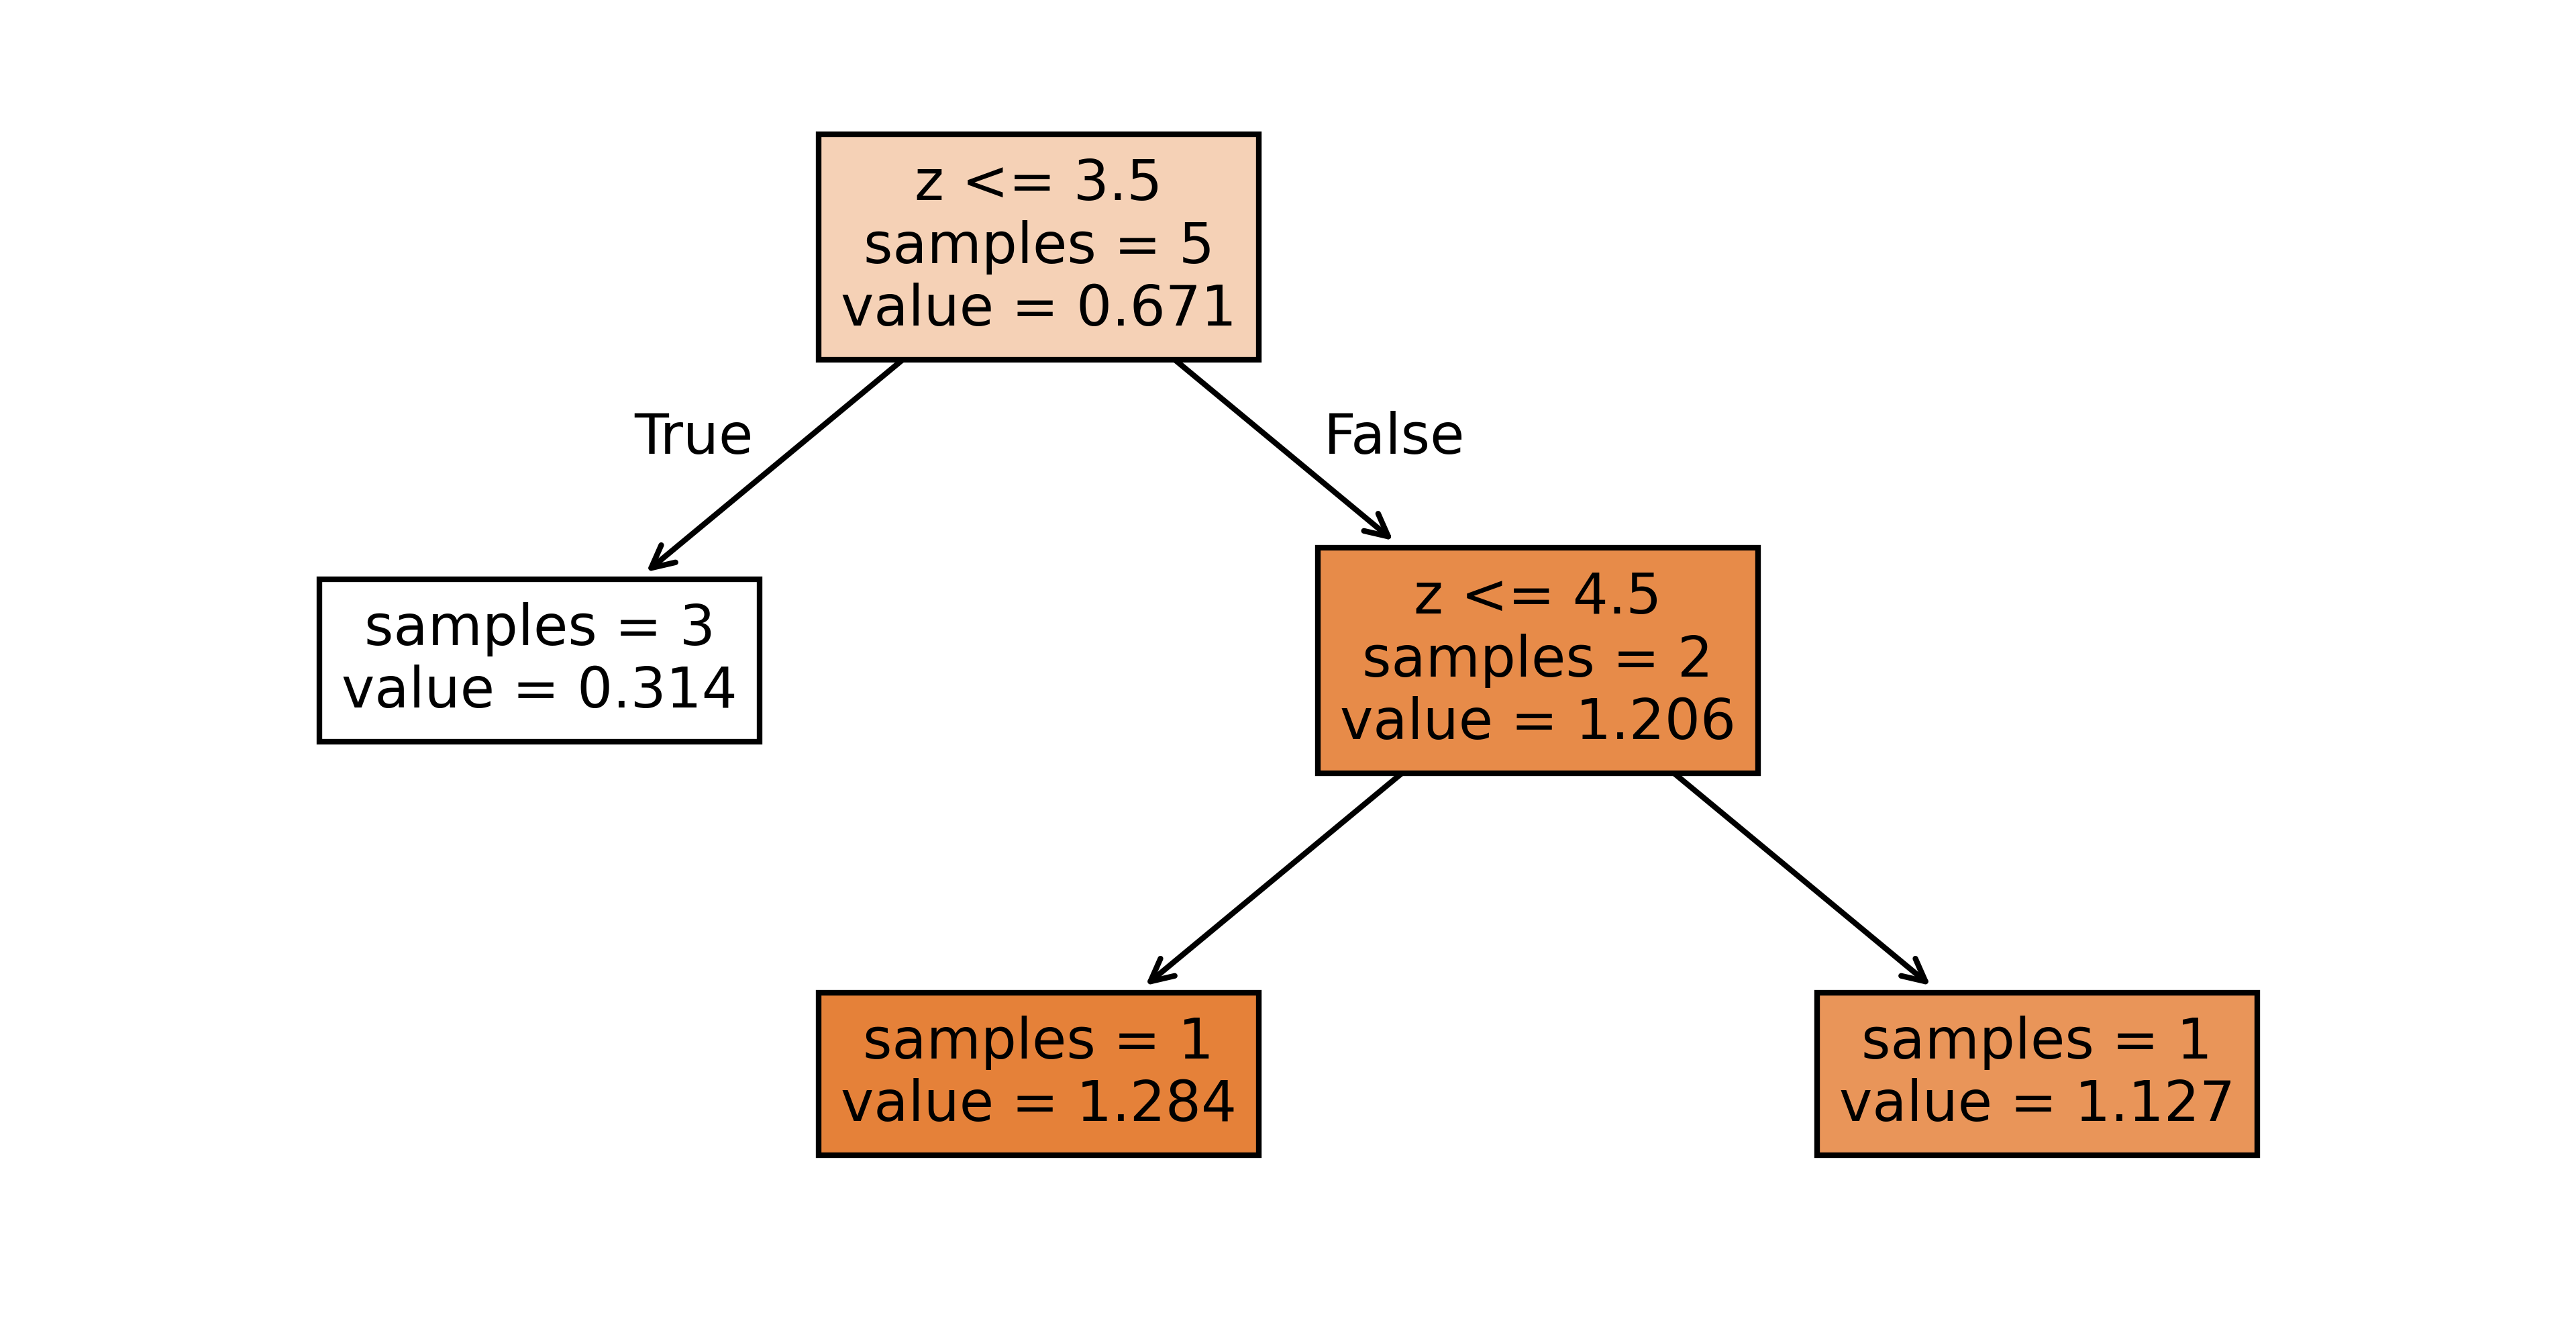

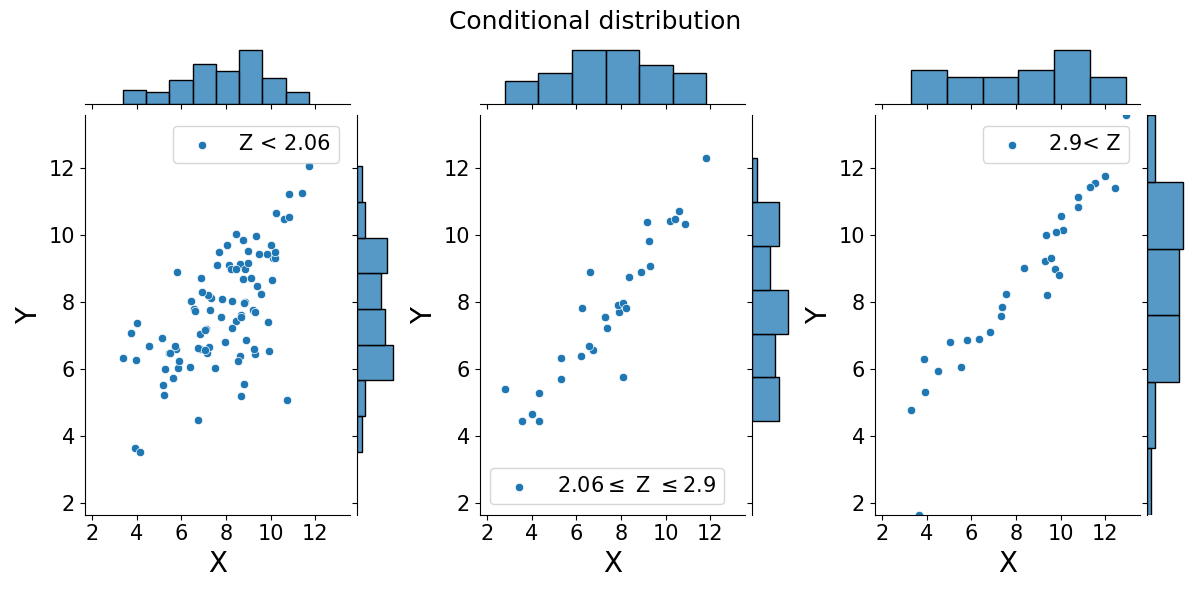

In [14]:
name_X = 'GATA1'
name_Y = 'KLF1'
name_Z = 'ETV1'

X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 10000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1, th2, c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True, disp_tree=True, name=None)
I = [0,1,2]
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])